# Adversarial Attack Evaluation for a Pretrained Adversarial-Training Model

This notebook:

- loads a **pretrained adversarial-training model** from **Google Drive**
- loads the **clean dataset** from **Google Drive**
- evaluates the model on:
  - **clean**
  - **FGSM** with one chosen epsilon
  - **PGD** with one chosen epsilon
- shows **separate progress bars** for FGSM and PGD
- saves metrics, confusion matrices, and a summary CSV/JSON to Drive

**Chosen epsilons**
- **FGSM = 2/255**
- **PGD = 1/255**

These are compact and informative choices for a single-epsilon evaluation.

In [ ]:
# ================================================================
# CELL 1 — Imports
# ================================================================
import os
import json
import math
import random
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    balanced_accuracy_score, roc_auc_score, confusion_matrix
)

from tqdm.auto import tqdm

try:
    import timm
except ImportError:
    !pip -q install timm
    import timm

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("DEVICE:", DEVICE)

DEVICE: cuda


In [ ]:
# ================================================================
# CELL 2 — Mount Google Drive
# ================================================================
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# ================================================================
# CELL 3 — Paths & Configuration
# ================================================================
DRIVE_ROOT = Path('/content/drive/MyDrive')

# # Parent folder used in your previous notebooks
# PROJECT_ROOT = DRIVE_ROOT / 'outputs_swin_lccfasd_robust2'

# # Clean dataset from Drive
# DATA_ROOT = PROJECT_ROOT / 'clean_dataset'

# # Pretrained adversarial-training model from Drive
# # Change only this line if your model is stored somewhere else.
# MODEL_PATH = PROJECT_ROOT / 'strategy_AT_PGD_only' / 'best_model.pth'


PROJECT_ROOT = DRIVE_ROOT / 'outputs_swin_lccfasd_robust2'

# Dossiers à l'intérieur du dossier projet
DATA_ROOT  = PROJECT_ROOT / 'clean_dataset'
MODEL_PATH = PROJECT_ROOT / 'strategy_AT_PGD_only' / 'checkpoint_epoch_5.pth'



# Where attack-evaluation outputs will be saved
OUT_ROOT = PROJECT_ROOT / 'attack_eval_single_eps_at_model'
OUT_ROOT.mkdir(parents=True, exist_ok=True)

SPLITS = {
    'test': DATA_ROOT / 'test'
}

MODEL_NAME  = 'swin_base_patch4_window7_224'
NUM_CLASSES = 2
IMG_SIZE    = 224
MEAN        = [0.485, 0.456, 0.406]
STD         = [0.229, 0.224, 0.225]

CFG = {
    'batch_size': 16,
    'num_workers': 2,

    # Single-epsilon evaluation
    'eps_fgsm': 2/255,
    'eps_pgd' : 4/255,
    'pgd_steps': 7,
    'pgd_alpha': 1/255,
}

print("="*70)
print("CONFIG")
print("="*70)
print("DATA_ROOT   :", DATA_ROOT)
print("TEST SPLIT  :", SPLITS['test'], "| exists =", SPLITS['test'].exists())
print("MODEL_PATH  :", MODEL_PATH, "| exists =", MODEL_PATH.exists())
print("OUT_ROOT    :", OUT_ROOT)
print("-"*70)
for k, v in CFG.items():
    print(f"{k:<12}: {v}")

CONFIG
DATA_ROOT   : /content/drive/MyDrive/outputs_swin_lccfasd_robust2/clean_dataset
TEST SPLIT  : /content/drive/MyDrive/outputs_swin_lccfasd_robust2/clean_dataset/test | exists = True
MODEL_PATH  : /content/drive/MyDrive/outputs_swin_lccfasd_robust2/strategy_AT_PGD_only/checkpoint_epoch_5.pth | exists = True
OUT_ROOT    : /content/drive/MyDrive/outputs_swin_lccfasd_robust2/attack_eval_single_eps_at_model
----------------------------------------------------------------------
batch_size  : 16
num_workers : 2
eps_fgsm    : 0.00784313725490196
eps_pgd     : 0.01568627450980392
pgd_steps   : 7
pgd_alpha   : 0.00392156862745098


In [ ]:
# ================================================================
# CELL 4 — Reproducibility
# ================================================================
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(42)
print("Seeds fixed.")

Seeds fixed.


In [ ]:
# ================================================================
# CELL 5 — Dataset
# ================================================================
REAL_NAMES  = {'real'}
SPOOF_NAMES = {'spoof', 'fake', 'attack'}
IMG_EXTS    = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}

eval_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

class LCCFASDDataset(Dataset):
    '''
    Label convention:
      0 = real
      1 = spoof
    '''
    def __init__(self, split_dir, transform=None):
        self.transform = transform
        self.samples = []
        self.labels = []

        split_dir = Path(split_dir)
        for cls_dir in sorted(split_dir.iterdir()):
            if not cls_dir.is_dir():
                continue
            name = cls_dir.name.lower()
            if name in REAL_NAMES:
                label = 0
            elif name in SPOOF_NAMES:
                label = 1
            else:
                continue

            for f in cls_dir.rglob('*'):
                if f.is_file() and f.suffix.lower() in IMG_EXTS:
                    self.samples.append((f, label))
                    self.labels.append(label)

        if not self.samples:
            raise RuntimeError(f'No images found in {split_dir}')

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        img = Image.open(img_path).convert('RGB')
        if self.transform is not None:
            img = self.transform(img)
        return img, label

test_ds = LCCFASDDataset(SPLITS['test'], transform=eval_tf)
test_loader = DataLoader(
    test_ds,
    batch_size=CFG['batch_size'],
    shuffle=False,
    num_workers=CFG['num_workers'],
    pin_memory=True,
)

cnt = Counter(test_ds.labels)
print(f"Test images: {len(test_ds):,}")
print(f"  real : {cnt.get(0, 0):,}")
print(f"  spoof: {cnt.get(1, 0):,}")
print(f"  batches: {len(test_loader)}")

Test images: 7,580
  real : 314
  spoof: 7,266
  batches: 474


In [ ]:
# ================================================================
# CELL 6 — Model
# ================================================================
def build_model():
    model = timm.create_model(
        MODEL_NAME,
        pretrained=False,
        num_classes=NUM_CLASSES
    )
    return model.to(DEVICE)

def load_trained_model(model_path=MODEL_PATH):
    assert Path(model_path).exists(), f"Model not found: {model_path}"
    model = build_model()
    state = torch.load(model_path, map_location=DEVICE)

    # Accept either raw state_dict or checkpoint dict
    if isinstance(state, dict) and 'model' in state:
        state = state['model']

    model.load_state_dict(state, strict=False)
    model.eval()
    return model

model = load_trained_model()
print("Model loaded successfully from:", MODEL_PATH)

Model loaded successfully from: /content/drive/MyDrive/outputs_swin_lccfasd_robust2/strategy_AT_PGD_only/checkpoint_epoch_5.pth


In [ ]:
# ================================================================
# CELL 7 — Attack Helpers
# ================================================================
mean_t = torch.tensor(MEAN, device=DEVICE).view(1, 3, 1, 1)
std_t  = torch.tensor(STD,  device=DEVICE).view(1, 3, 1, 1)

def clamp_normalized(x):
    x_min = (0.0 - mean_t) / std_t
    x_max = (1.0 - mean_t) / std_t
    return torch.max(torch.min(x, x_max), x_min)

@torch.enable_grad()
def fgsm_attack(model, x, y, epsilon):
    x_adv = x.detach().clone().requires_grad_(True)
    logits = model(x_adv)
    loss = F.cross_entropy(logits, y)
    grad = torch.autograd.grad(loss, x_adv)[0]
    x_adv = x_adv + epsilon * grad.sign()
    x_adv = clamp_normalized(x_adv).detach()
    return x_adv

@torch.enable_grad()
def pgd_attack(model, x, y, epsilon, alpha, steps, random_start=True):
    x_orig = x.detach().clone()

    if random_start:
        delta = torch.empty_like(x_orig).uniform_(-epsilon, epsilon)
        x_adv = clamp_normalized(x_orig + delta)
    else:
        x_adv = x_orig.clone()

    for _ in range(steps):
        x_adv = x_adv.detach().requires_grad_(True)
        logits = model(x_adv)
        loss = F.cross_entropy(logits, y)
        grad = torch.autograd.grad(loss, x_adv)[0]

        x_adv = x_adv + alpha * grad.sign()
        delta = torch.clamp(x_adv - x_orig, min=-epsilon, max=epsilon)
        x_adv = clamp_normalized(x_orig + delta).detach()

    return x_adv

In [ ]:
# ================================================================
# CELL 8 — Metrics Helpers
# ================================================================
def compute_far_frr_hter(cm):
    # Convention:
    #   0 = real
    #   1 = spoof
    # cm = [[real->real, real->spoof],
    #       [spoof->real, spoof->spoof]]
    tn = cm[0, 0]  # real correctly accepted as real
    fp = cm[0, 1]  # real rejected as spoof
    fn = cm[1, 0]  # spoof accepted as real
    tp = cm[1, 1]  # spoof correctly rejected as spoof

    # In anti-spoofing terms:
    # FAR = spoof accepted as real = fn / (fn + tp)
    # FRR = real rejected as spoof = fp / (fp + tn)
    far = 100.0 * fn / max((fn + tp), 1)
    frr = 100.0 * fp / max((fp + tn), 1)
    hter = (far + frr) / 2.0
    return far, frr, hter

def evaluate(model, loader, attack=None, attack_name="clean", attack_kwargs=None):
    model.eval()
    attack_kwargs = attack_kwargs or {}

    y_true, y_pred = [], []
    y_score = []
    running_loss = 0.0

    pbar = tqdm(loader, desc=f"Evaluating {attack_name}", leave=False)
    for x, y in pbar:
        x = x.to(DEVICE, non_blocking=True)
        y = y.to(DEVICE, non_blocking=True)

        if attack is not None:
            x = attack(model, x, y, **attack_kwargs)

        with torch.no_grad():
            logits = model(x)
            loss = F.cross_entropy(logits, y)
            probs = torch.softmax(logits, dim=1)[:, 1]
            preds = torch.argmax(logits, dim=1)

        running_loss += loss.item() * x.size(0)

        y_true.extend(y.cpu().numpy().tolist())
        y_pred.extend(preds.cpu().numpy().tolist())
        y_score.extend(probs.cpu().numpy().tolist())

        pbar.set_postfix(loss=f"{loss.item():.4f}")

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    y_score = np.array(y_score)

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    far, frr, hter = compute_far_frr_hter(cm)

    try:
        auc = roc_auc_score(y_true, y_score) * 100
    except Exception:
        auc = float('nan')

    metrics = {
        'acc': accuracy_score(y_true, y_pred) * 100,
        'prec_macro': precision_score(y_true, y_pred, average='macro', zero_division=0) * 100,
        'rec_macro': recall_score(y_true, y_pred, average='macro', zero_division=0) * 100,
        'f1_macro': f1_score(y_true, y_pred, average='macro', zero_division=0) * 100,
        'bacc': balanced_accuracy_score(y_true, y_pred) * 100,
        'hter': hter,
        'far': far,
        'frr': frr,
        'auc': auc,
        'loss': running_loss / len(loader.dataset),
        'cm': cm.tolist(),
    }
    return metrics

def pretty_print_results(title, metrics):
    print("=" * 42)
    print(title)
    print("=" * 42)
    print(f"Loss            : {metrics['loss']:.4f}")
    print(f"Accuracy        : {metrics['acc']:.2f}%")
    print(f"Balanced Acc    : {metrics['bacc']:.2f}%")
    print(f"Precision Macro : {metrics['prec_macro']:.2f}%")
    print(f"Recall Macro    : {metrics['rec_macro']:.2f}%")
    print(f"F1 Macro        : {metrics['f1_macro']:.2f}%")
    print(f"HTER            : {metrics['hter']:.2f}%")
    print(f"FAR             : {metrics['far']:.2f}%")
    print(f"FRR             : {metrics['frr']:.2f}%")
    print(f"AUC             : {metrics['auc']/100:.4f}" if metrics['auc'] > 1 else f"AUC             : {metrics['auc']:.4f}")
    print("=" * 42)

def save_json(obj, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, 'w') as f:
        json.dump(obj, f, indent=2)

def plot_cm(cm, title, save_path):
    cm = np.array(cm)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['real', 'spoof'],
                yticklabels=['real', 'spoof'])
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title(title)
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

Evaluating clean:   0%|          | 0/474 [00:00<?, ?it/s]

CLEAN EVALUATION
Loss            : 0.1904
Accuracy        : 92.81%
Balanced Acc    : 88.17%
Precision Macro : 66.94%
Recall Macro    : 88.17%
F1 Macro        : 72.53%
HTER            : 11.83%
FAR             : 6.77%
FRR             : 16.88%
AUC             : 0.9328


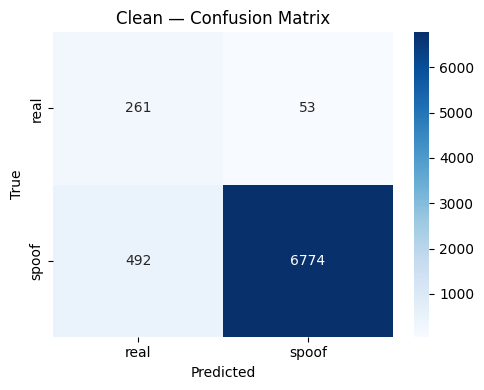

In [ ]:
# ================================================================
# CELL 9 — Clean Evaluation
# ================================================================
clean_metrics = evaluate(model, test_loader, attack=None, attack_name="clean")
pretty_print_results("CLEAN EVALUATION", clean_metrics)

save_json(clean_metrics, OUT_ROOT / 'clean_metrics.json')
plot_cm(clean_metrics['cm'], 'Clean — Confusion Matrix', OUT_ROOT / 'cm_clean.png')

Running FGSM with epsilon = 0.007843 (2.0/255)


Evaluating FGSM:   0%|          | 0/474 [00:00<?, ?it/s]

FGSM EVALUATION
Loss            : 0.2782
Accuracy        : 89.50%
Balanced Acc    : 84.16%
Precision Macro : 62.11%
Recall Macro    : 84.16%
F1 Macro        : 66.23%
HTER            : 15.84%
FAR             : 10.02%
FRR             : 21.66%
AUC             : 0.8781


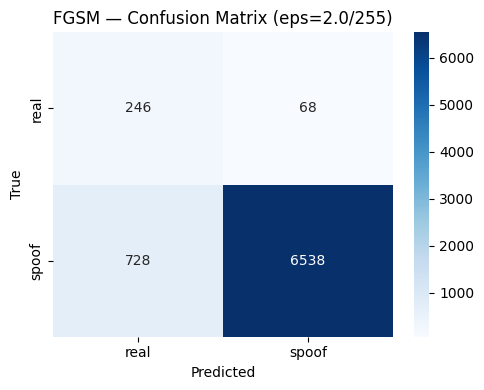

In [ ]:
# ================================================================
# CELL 10 — FGSM Evaluation (separate progress)
# ================================================================
print(f"Running FGSM with epsilon = {CFG['eps_fgsm']:.6f} ({CFG['eps_fgsm']*255:.1f}/255)")
fgsm_metrics = evaluate(
    model,
    test_loader,
    attack=fgsm_attack,
    attack_name="FGSM",
    attack_kwargs={'epsilon': CFG['eps_fgsm']}
)
pretty_print_results("FGSM EVALUATION", fgsm_metrics)

save_json(fgsm_metrics, OUT_ROOT / 'fgsm_metrics.json')
plot_cm(fgsm_metrics['cm'], f'FGSM — Confusion Matrix (eps={CFG["eps_fgsm"]*255:.1f}/255)', OUT_ROOT / 'cm_fgsm.png')

Running PGD with epsilon = 0.015686 (4.0/255)


Evaluating PGD:   0%|          | 0/474 [00:00<?, ?it/s]

PGD EVALUATION
Loss            : 0.4083
Accuracy        : 84.91%
Balanced Acc    : 78.87%
Precision Macro : 58.15%
Recall Macro    : 78.87%
F1 Macro        : 59.99%
HTER            : 21.13%
FAR             : 14.55%
FRR             : 27.71%
AUC             : 0.8095


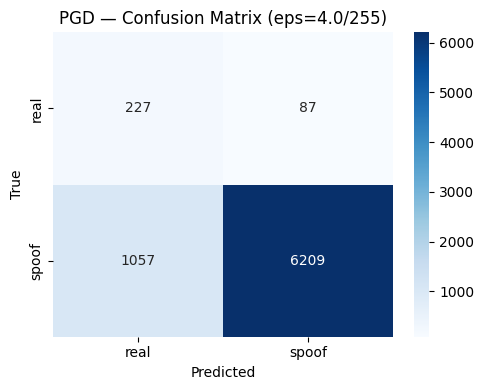

In [ ]:
# ================================================================
# CELL 11 — PGD Evaluation (separate progress)
# ================================================================
print(f"Running PGD with epsilon = {CFG['eps_pgd']:.6f} ({CFG['eps_pgd']*255:.1f}/255)")
pgd_metrics = evaluate(
    model,
    test_loader,
    attack=pgd_attack,
    attack_name="PGD",
    attack_kwargs={
        'epsilon': CFG['eps_pgd'],
        'alpha': CFG['pgd_alpha'],
        'steps': CFG['pgd_steps'],
        'random_start': True
    }
)
pretty_print_results("PGD EVALUATION", pgd_metrics)

save_json(pgd_metrics, OUT_ROOT / 'pgd_metrics.json')
plot_cm(pgd_metrics['cm'], f'PGD — Confusion Matrix (eps={CFG["eps_pgd"]*255:.1f}/255)', OUT_ROOT / 'cm_pgd.png')

,setting,acc,prec_macro,rec_macro,f1_macro,bacc,hter,far,frr,auc,loss
0,clean,92.810026,66.942513,88.174878,72.527522,88.174878,11.825122,6.771263,16.878981,93.276073,0.190397
1,fgsm,89.498681,62.113653,84.162341,66.230290,84.162341,15.837659,10.019268,21.656051,87.807229,0.278232
2,pgd,84.907652,58.148649,78.872894,59.987590,78.872894,21.127106,14.547206,27.707006,80.947165,0.408268


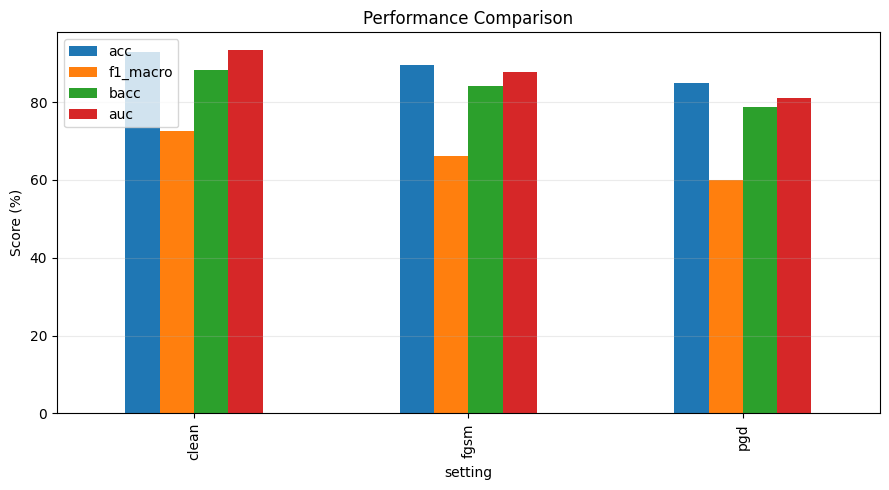

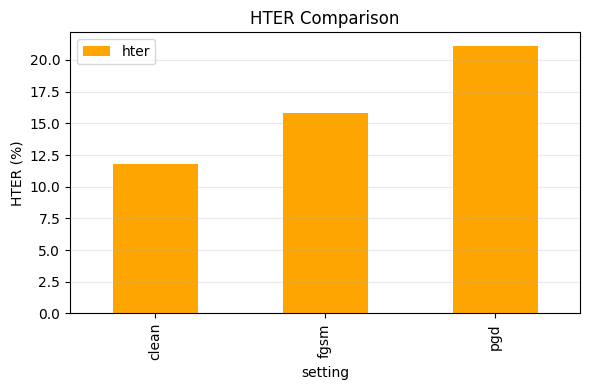

Saved all results to: /content/drive/MyDrive/outputs_swin_lccfasd_robust2/attack_eval_single_eps_at_model


In [ ]:
# ================================================================
# CELL 12 — Final Comparison + Save CSV
# ================================================================
summary_df = pd.DataFrame([
    {'setting': 'clean', **{k:v for k,v in clean_metrics.items() if k != 'cm'}},
    {'setting': 'fgsm',  **{k:v for k,v in fgsm_metrics.items() if k != 'cm'}},
    {'setting': 'pgd',   **{k:v for k,v in pgd_metrics.items() if k != 'cm'}},
])

display(summary_df)
summary_df.to_csv(OUT_ROOT / 'summary_metrics.csv', index=False)

plot_df = summary_df[['setting', 'acc', 'f1_macro', 'bacc', 'hter', 'auc']].copy()
plot_df = plot_df.set_index('setting')

ax = plot_df[['acc', 'f1_macro', 'bacc', 'auc']].plot(kind='bar', figsize=(9, 5))
plt.title('Performance Comparison')
plt.ylabel('Score (%)')
plt.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.savefig(OUT_ROOT / 'comparison_scores.png', dpi=300, bbox_inches='tight')
plt.show()

ax = plot_df[['hter']].plot(kind='bar', figsize=(6, 4), color='orange')
plt.title('HTER Comparison')
plt.ylabel('HTER (%)')
plt.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.savefig(OUT_ROOT / 'comparison_hter.png', dpi=300, bbox_inches='tight')
plt.show()

print("Saved all results to:", OUT_ROOT)